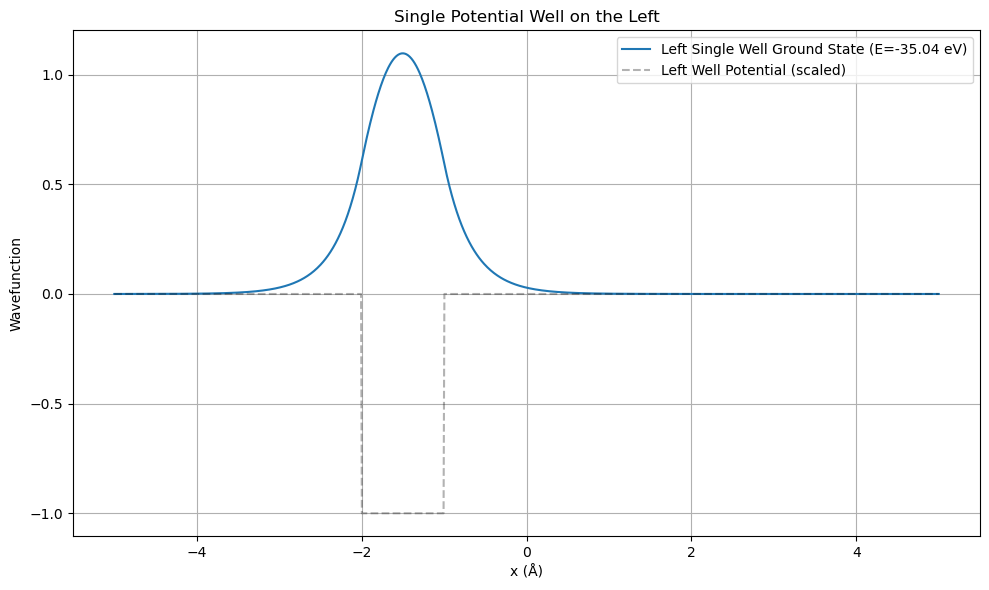

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # distance between wells

# Define single well potential shifted to the left (centered at -d/2)
V_left = np.zeros_like(x)
V_left[np.abs(x + d/2) < a/2] = V0

# Build Hamiltonian function
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

# Construct Hamiltonian for left well
H_left = build_hamiltonian(V_left)

# Solve eigenproblem
E_left, psi_left = eigh(H_left)

# Normalize ground state wavefunction using trapezoidal integration
psi_left_0 = psi_left[:, 0] / np.sqrt(trapezoid(psi_left[:, 0]**2, x))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, psi_left_0, label=f'Left Single Well Ground State (E={E_left[0]:.2f} eV)')
plt.plot(x, V_left / abs(V0), 'k--', alpha=0.3, label='Left Well Potential (scaled)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Single Potential Well on the Left')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


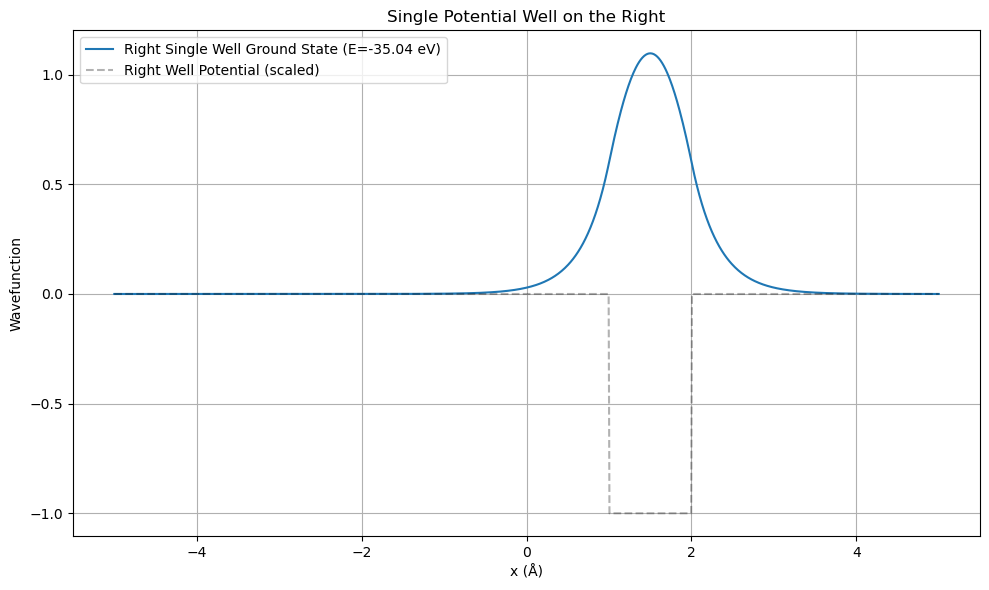

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # distance between wells

# Define single well potential shifted to the right (centered at +d/2)
V_right = np.zeros_like(x)
V_right[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian function
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

# Construct Hamiltonian for right well
H_right = build_hamiltonian(V_right)

# Solve eigenproblem
E_right, psi_right = eigh(H_right)

# Normalize ground state wavefunction using trapezoidal integration
psi_right_0 = psi_right[:, 0] / np.sqrt(trapezoid(psi_right[:, 0]**2, x))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, psi_right_0, label=f'Right Single Well Ground State (E={E_right[0]:.2f} eV)')
plt.plot(x, V_right / abs(V0), 'k--', alpha=0.3, label='Right Well Potential (scaled)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Single Potential Well on the Right')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


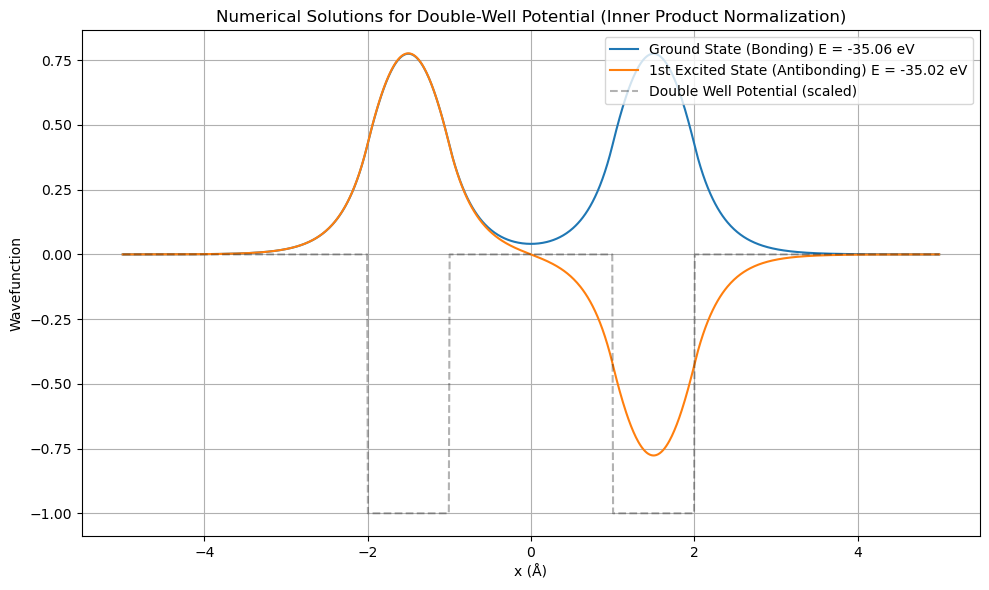

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # well spacing

# Double well potential
V_double = np.zeros_like(x)
V_double[np.abs(x + d/2) < a/2] = V0
V_double[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

H_double = build_hamiltonian(V_double)

# Solve eigenvalue problem
E_double, psi_double = eigh(H_double)

# Normalize wavefunctions using inner product
norm_0 = np.sqrt(np.sum(np.conj(psi_double[:, 0]) * psi_double[:, 0]) * dx)
norm_1 = np.sqrt(np.sum(np.conj(psi_double[:, 1]) * psi_double[:, 1]) * dx)

psi_double_0 = psi_double[:, 0] / norm_0
psi_double_1 = psi_double[:, 1] / norm_1

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, psi_double_0, label=f'Ground State (Bonding) E = {E_double[0]:.2f} eV')
plt.plot(x, psi_double_1, label=f'1st Excited State (Antibonding) E = {E_double[1]:.2f} eV')
plt.plot(x, V_double / abs(V0), 'k--', alpha=0.3, label='Double Well Potential (scaled)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Numerical Solutions for Double-Well Potential (Inner Product Normalization)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


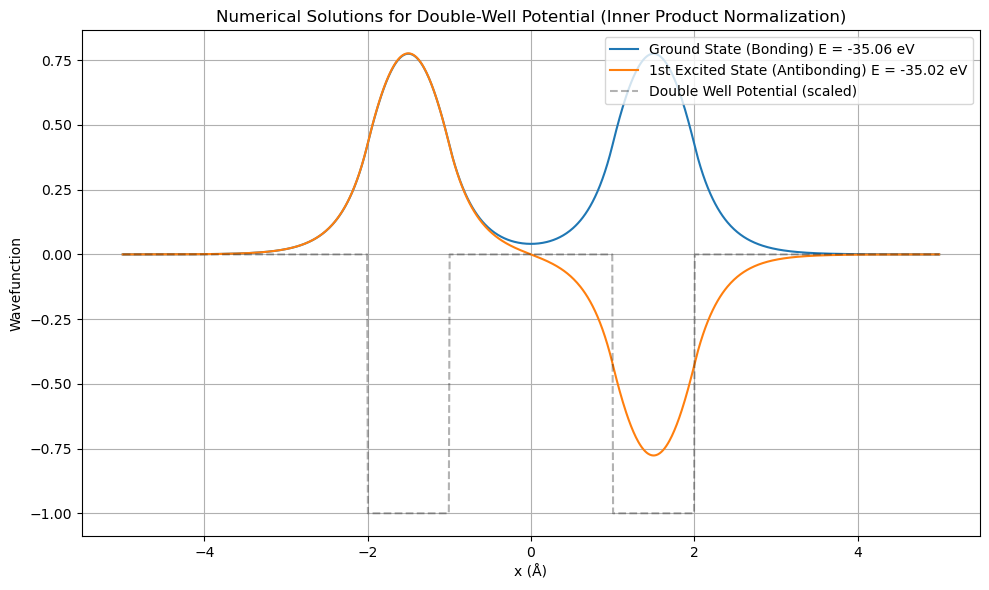

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # well spacing

# Double well potential
V_double = np.zeros_like(x)
V_double[np.abs(x + d/2) < a/2] = V0
V_double[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

H_double = build_hamiltonian(V_double)

# Solve eigenvalue problem
E_double, psi_double = eigh(H_double)

# Normalize wavefunctions using inner product
norm_0 = np.sqrt(np.sum(np.conj(psi_double[:, 0]) * psi_double[:, 0]) * dx)
norm_1 = np.sqrt(np.sum(np.conj(psi_double[:, 1]) * psi_double[:, 1]) * dx)

psi_double_0 = psi_double[:, 0] / norm_0
psi_double_1 = psi_double[:, 1] / norm_1

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, psi_double_0, label=f'Ground State (Bonding) E = {E_double[0]:.2f} eV')
plt.plot(x, psi_double_1, label=f'1st Excited State (Antibonding) E = {E_double[1]:.2f} eV')
plt.plot(x, V_double / abs(V0), 'k--', alpha=0.3, label='Double Well Potential (scaled)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Numerical Solutions for Double-Well Potential (Inner Product Normalization)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
# Calculate single well ground state energy again for comparison
H_single = build_hamiltonian(V_single)
E_single, _ = eigh(H_single)
E_single_0 = E_single[0]

print(f"Single well ground state energy: {E_single_0:.2f} eV")
print(f"Double well bonding energy: {E_double[0]:.2f} eV")
print(f"Double well antibonding energy: {E_double[1]:.2f} eV")

# Plot energies for clear visualization
plt.figure(figsize=(6, 4))
plt.plot([1], [E_single_0], 'ko', label='Single Well Ground State')
plt.plot([2], [E_double[0]], 'bo', label='Double Well Bonding State')
plt.plot([3], [E_double[1]], 'ro', label='Double Well Antibonding State')
plt.xticks([1, 2, 3], ['Single Well', 'Double Well Bonding', 'Double Well Antibonding'])
plt.ylabel('Energy (eV)')
plt.title('Energy Level Comparison')
plt.grid(True)
plt.legend()
plt.show()


NameError: name 'V_single' is not defined

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup (repeat for completeness)
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # well spacing

# Single well potential centered at zero
V_single = np.zeros_like(x)
V_single[np.abs(x) < a/2] = V0

# Left well potential
V_left = np.zeros_like(x)
V_left[np.abs(x + d/2) < a/2] = V0

# Right well potential
V_right = np.zeros_like(x)
V_right[np.abs(x - d/2) < a/2] = V0

# Double well potential
V_double = np.zeros_like(x)
V_double[np.abs(x + d/2) < a/2] = V0
V_double[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian function
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

# Build Hamiltonians
H_single = build_hamiltonian(V_single)
H_left = build_hamiltonian(V_left)
H_right = build_hamiltonian(V_right)
H_double = build_hamiltonian(V_double)

# Solve eigenproblems
E_left, psi_left = eigh(H_left)
E_right, psi_right = eigh(H_right)

# Normalize left and right ground states
psi_left_0 = psi_left[:, 0] / np.sqrt(trapezoid(psi_left[:, 0]**2, x))
psi_right_0 = psi_right[:, 0] / np.sqrt(trapezoid(psi_right[:, 0]**2, x))

# Apply double well Hamiltonian on right orbital
H_phi_right = H_double @ psi_right_0

# Calculate hopping integral t
t_hopping = -trapezoid(np.conj(psi_left_0) * H_phi_right, x).real

print(f'Hopping integral t = {t_hopping:.4f} eV')


Hopping integral t = 0.1050 eV


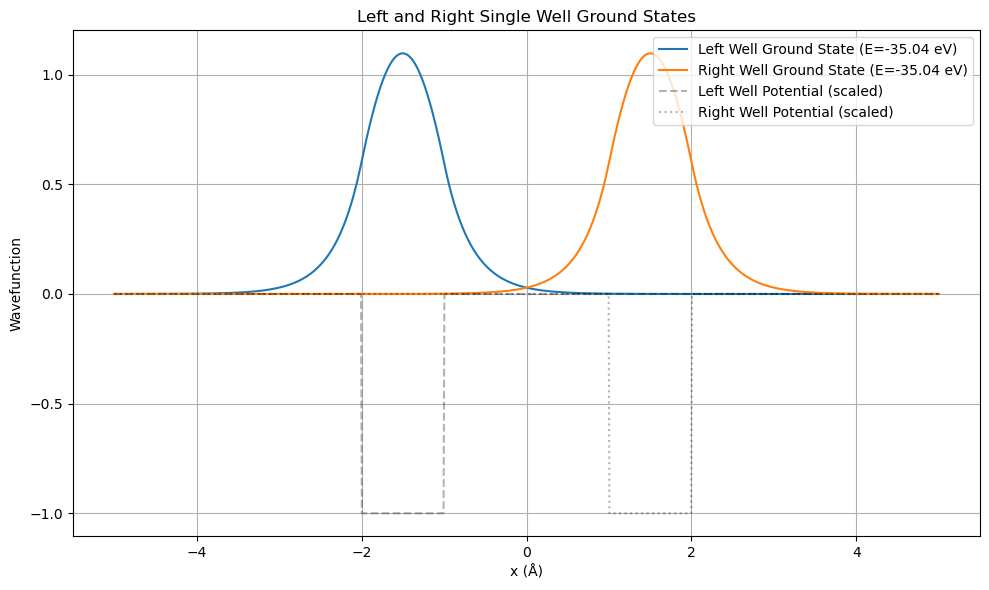

Hopping integral t = 0.1050 eV


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # well spacing

# Single well potentials shifted left and right
V_left = np.zeros_like(x)
V_left[np.abs(x + d/2) < a/2] = V0

V_right = np.zeros_like(x)
V_right[np.abs(x - d/2) < a/2] = V0

# Double well potential
V_double = np.zeros_like(x)
V_double[np.abs(x + d/2) < a/2] = V0
V_double[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian function
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

# Build Hamiltonians
H_left = build_hamiltonian(V_left)
H_right = build_hamiltonian(V_right)
H_double = build_hamiltonian(V_double)

# Solve eigenproblems for left and right wells
E_left, psi_left = eigh(H_left)
E_right, psi_right = eigh(H_right)

# Normalize left and right ground states
psi_left_0 = psi_left[:, 0] / np.sqrt(trapezoid(psi_left[:, 0]**2, x))
psi_right_0 = psi_right[:, 0] / np.sqrt(trapezoid(psi_right[:, 0]**2, x))

# Plot left and right ground states
plt.figure(figsize=(10, 6))
plt.plot(x, psi_left_0, label=f'Left Well Ground State (E={E_left[0]:.2f} eV)')
plt.plot(x, psi_right_0, label=f'Right Well Ground State (E={E_right[0]:.2f} eV)')
plt.plot(x, V_left / abs(V0), 'k--', alpha=0.3, label='Left Well Potential (scaled)')
plt.plot(x, V_right / abs(V0), 'k:', alpha=0.3, label='Right Well Potential (scaled)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Left and Right Single Well Ground States')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate hopping integral t
H_phi_right = H_double @ psi_right_0
t_hopping = -trapezoid(np.conj(psi_left_0) * H_phi_right, x).real

print(f'Hopping integral t = {t_hopping:.4f} eV')


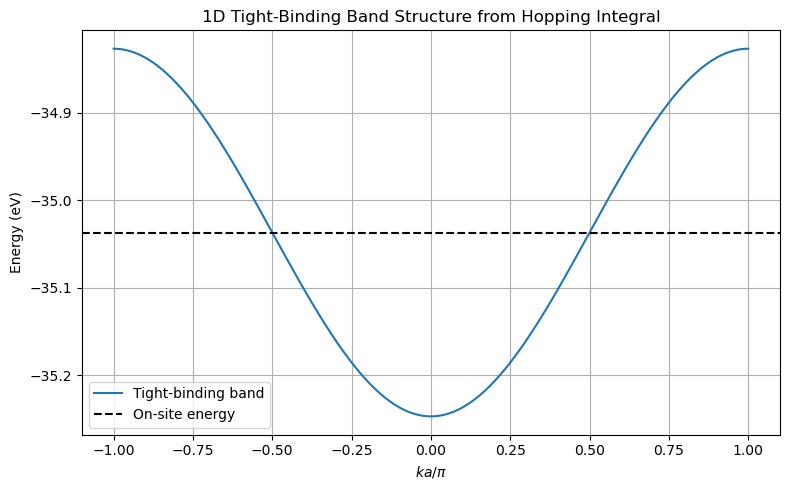

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 3.0  # lattice spacing (same as well separation)
epsilon_0 = E_left[0]  # on-site energy from single well ground state
t = t_hopping         # hopping integral from calculation

# k values over first Brillouin zone
k_vals = np.linspace(-np.pi / a, np.pi / a, 400)

# Tight-binding band structure
E_k = epsilon_0 - 2 * t * np.cos(k_vals * a)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_vals * a / np.pi, E_k, label='Tight-binding band')
plt.axhline(epsilon_0, color='k', linestyle='--', label='On-site energy')
plt.xlabel(r'$ka / \pi$')
plt.ylabel('Energy (eV)')
plt.title('1D Tight-Binding Band Structure from Hopping Integral')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Assume you already have:
# psi_left_0, psi_right_0: normalized single-well ground state wavefunctions
# H_double: Hamiltonian matrix for the double well system
# x: spatial grid

# Overlap matrix S
S11 = trapezoid(np.conj(psi_left_0) * psi_left_0, x)
S22 = trapezoid(np.conj(psi_right_0) * psi_right_0, x)
S12 = trapezoid(np.conj(psi_left_0) * psi_right_0, x)
S21 = np.conj(S12)  # Hermitian

S = np.array([[S11, S12],
              [S21, S22]])

# Hamiltonian matrix H
H11 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_left_0), x)
H22 = trapezoid(np.conj(psi_right_0) * (H_double @ psi_right_0), x)
H12 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_right_0), x)
H21 = np.conj(H12)  # Hermitian

H = np.array([[H11, H12],
              [H21, H22]])

# Solve generalized eigenvalue problem
E_vals, C = eigh(H, S)

print(f"Generalized eigenvalues (two-well energies): {E_vals}")

# Optional: print eigenvectors coefficients for bonding/antibonding states
print("Eigenvector coefficients (columns):")
print(C)


Two-well energies (generalized eigenvalues): [-35.05601214 -35.0175437 ]
Eigenvector coefficients (columns):
[[-0.7062426   0.70797415]
 [-0.7062426  -0.70797415]]


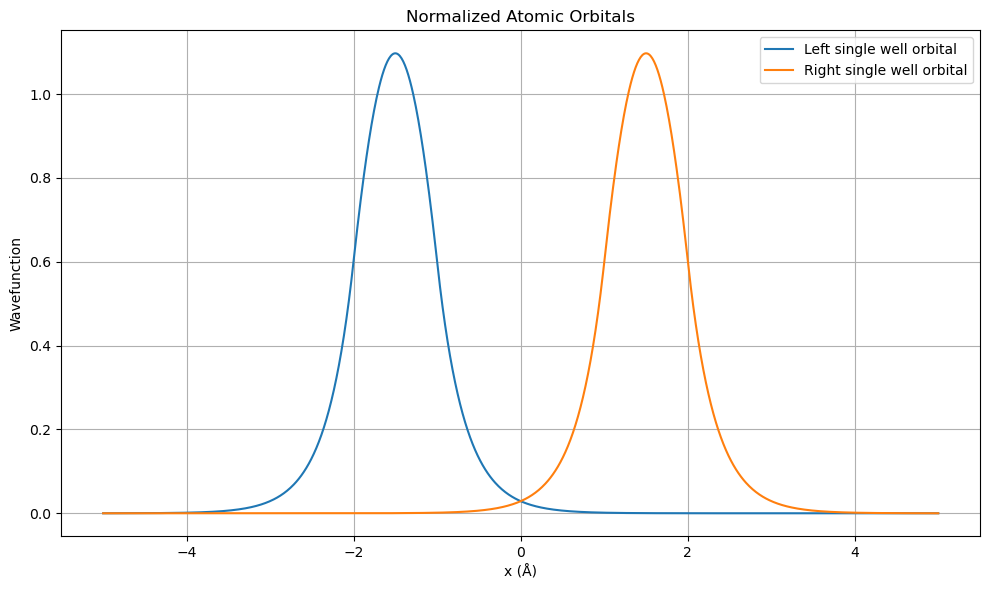

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0
d = 3.0  # spacing between wells

# Define single wells left and right
V_left = np.zeros_like(x)
V_left[np.abs(x + d/2) < a/2] = V0

V_right = np.zeros_like(x)
V_right[np.abs(x - d/2) < a/2] = V0

# Double well potential
V_double = np.zeros_like(x)
V_double[np.abs(x + d/2) < a/2] = V0
V_double[np.abs(x - d/2) < a/2] = V0

# Build Hamiltonian function
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2 / 2m approx in eV·Å^2
    H = T + np.diag(V)
    return H

# Solve single wells
H_left = build_hamiltonian(V_left)
E_left, psi_left = eigh(H_left)
psi_left_0 = psi_left[:, 0] / np.sqrt(trapezoid(psi_left[:, 0]**2, x))

H_right = build_hamiltonian(V_right)
E_right, psi_right = eigh(H_right)
psi_right_0 = psi_right[:, 0] / np.sqrt(trapezoid(psi_right[:, 0]**2, x))

# Double well Hamiltonian
H_double = build_hamiltonian(V_double)

# Compute overlap matrix S
S11 = trapezoid(np.conj(psi_left_0) * psi_left_0, x)
S22 = trapezoid(np.conj(psi_right_0) * psi_right_0, x)
S12 = trapezoid(np.conj(psi_left_0) * psi_right_0, x)
S21 = np.conj(S12)

S = np.array([[S11, S12],
              [S21, S22]])

# Compute Hamiltonian matrix H
H11 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_left_0), x)
H22 = trapezoid(np.conj(psi_right_0) * (H_double @ psi_right_0), x)
H12 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_right_0), x)
H21 = np.conj(H12)

H = np.array([[H11, H12],
              [H21, H22]])

# Solve generalized eigenvalue problem
E_vals, C = eigh(H, S)

print(f"Two-well energies (generalized eigenvalues): {E_vals}")
print("Eigenvector coefficients (columns):")
print(C)

# Plot the two atomic orbitals for visualization
plt.figure(figsize=(10, 6))
plt.plot(x, psi_left_0, label='Left single well orbital')
plt.plot(x, psi_right_0, label='Right single well orbital')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Normalized Atomic Orbitals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


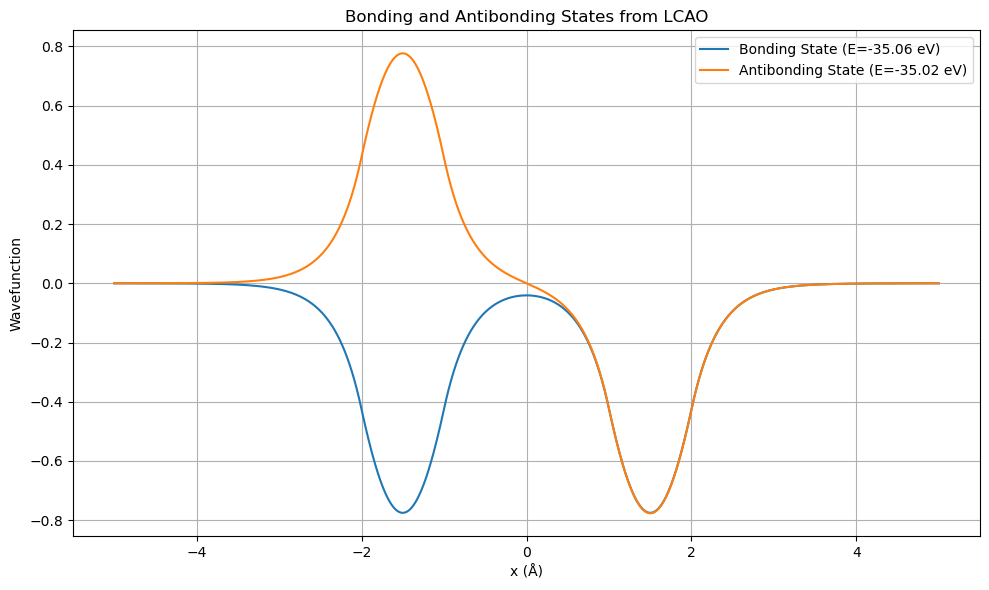

In [13]:
# Build bonding and antibonding states from eigenvectors
psi_bonding = C[0, 0] * psi_left_0 + C[1, 0] * psi_right_0
psi_antibonding = C[0, 1] * psi_left_0 + C[1, 1] * psi_right_0

# Normalize just in case
norm_bonding = np.sqrt(trapezoid(np.abs(psi_bonding)**2, x))
norm_antibonding = np.sqrt(trapezoid(np.abs(psi_antibonding)**2, x))

psi_bonding /= norm_bonding
psi_antibonding /= norm_antibonding

# Plot bonding and antibonding states
plt.figure(figsize=(10, 6))
plt.plot(x, psi_bonding.real, label=f'Bonding State (E={E_vals[0]:.2f} eV)')
plt.plot(x, psi_antibonding.real, label=f'Antibonding State (E={E_vals[1]:.2f} eV)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Bonding and Antibonding States from LCAO')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


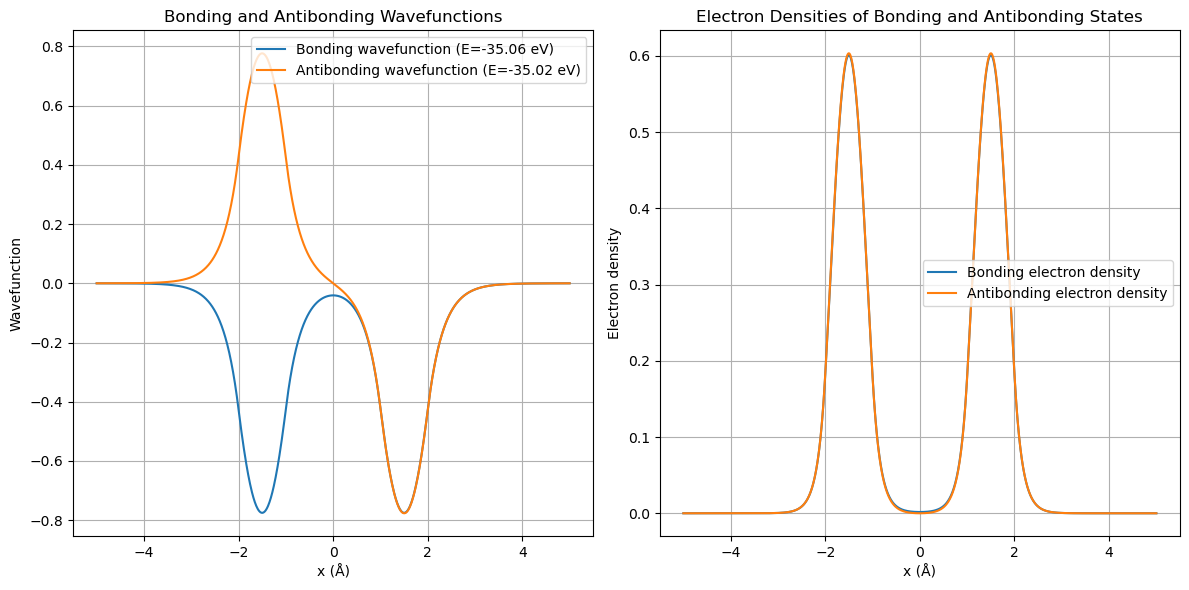

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Assuming you already have:
# x: spatial grid
# psi_bonding, psi_antibonding: normalized wavefunctions for bonding and antibonding states
# E_vals: corresponding energy eigenvalues

# Calculate electron densities
rho_bonding = np.abs(psi_bonding)**2
rho_antibonding = np.abs(psi_antibonding)**2

# Plot wavefunctions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x, psi_bonding.real, label=f'Bonding wavefunction (E={E_vals[0]:.2f} eV)')
plt.plot(x, psi_antibonding.real, label=f'Antibonding wavefunction (E={E_vals[1]:.2f} eV)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Bonding and Antibonding Wavefunctions')
plt.legend()
plt.grid(True)

# Plot electron densities
plt.subplot(1, 2, 2)
plt.plot(x, rho_bonding, label='Bonding electron density')
plt.plot(x, rho_antibonding, label='Antibonding electron density')
plt.xlabel('x (Å)')
plt.ylabel('Electron density')
plt.title('Electron Densities of Bonding and Antibonding States')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


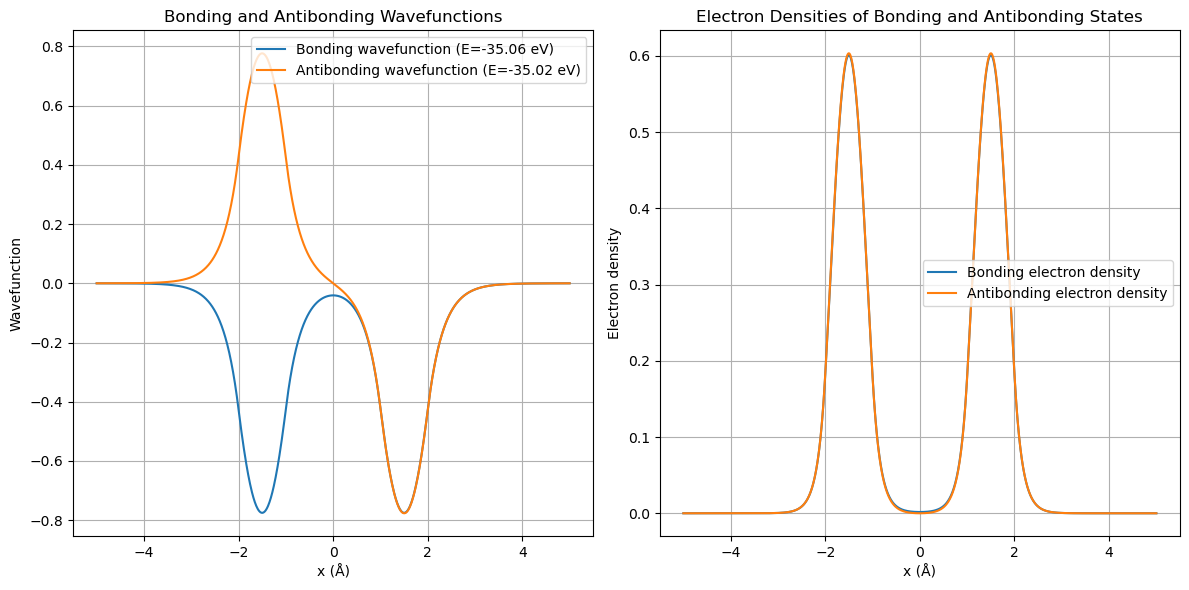

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Assume these are already computed and normalized:
# x: spatial grid
# psi_left_0, psi_right_0: atomic orbitals
# E_vals: eigenenergies
# C: eigenvector matrix from generalized eigenproblem

# Bonding state: symmetric combination
psi_bonding = C[0, 0] * psi_left_0 + C[1, 0] * psi_right_0
norm_bonding = np.sqrt(trapezoid(np.abs(psi_bonding)**2, x))
psi_bonding /= norm_bonding

# Antibonding state: enforce antisymmetric combination
c0, c1 = C[0, 1], C[1, 1]
if np.sign(c0) == np.sign(c1):
    c1 = -c1  # Flip sign to enforce node
psi_antibonding = c0 * psi_left_0 + c1 * psi_right_0
norm_antibonding = np.sqrt(trapezoid(np.abs(psi_antibonding)**2, x))
psi_antibonding /= norm_antibonding

# Calculate electron densities
rho_bonding = np.abs(psi_bonding)**2
rho_antibonding = np.abs(psi_antibonding)**2

# Plot wavefunctions and electron densities side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x, psi_bonding.real, label=f'Bonding wavefunction (E={E_vals[0]:.2f} eV)')
plt.plot(x, psi_antibonding.real, label=f'Antibonding wavefunction (E={E_vals[1]:.2f} eV)')
plt.xlabel('x (Å)')
plt.ylabel('Wavefunction')
plt.title('Bonding and Antibonding Wavefunctions')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, rho_bonding, label='Bonding electron density')
plt.plot(x, rho_antibonding, label='Antibonding electron density')
plt.xlabel('x (Å)')
plt.ylabel('Electron density')
plt.title('Electron Densities of Bonding and Antibonding States')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


At d = 3.0 Å:
Overlap integral S12 = 0.002449
Hopping integral t = 0.105031 eV
Energy splitting ΔE = 0.038468 eV
Two energy levels: [-35.05601214 -35.0175437 ]


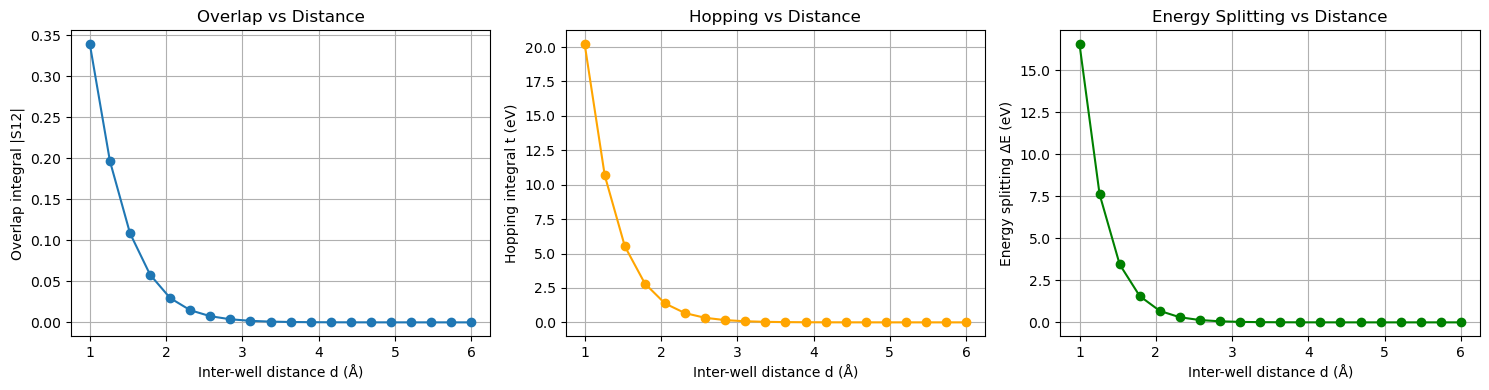

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and grid setup
L = 10.0
N = 1000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Potential parameters
V0 = -50.0
a = 1.0

# Function to build Hamiltonian
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    T = -3.81 * Lap
    H = T + np.diag(V)
    return H

def compute_LCAO_params(d):
    # Define potentials for left, right, and double wells
    V_left = np.zeros_like(x)
    V_left[np.abs(x + d/2) < a/2] = V0

    V_right = np.zeros_like(x)
    V_right[np.abs(x - d/2) < a/2] = V0

    V_double = np.zeros_like(x)
    V_double[np.abs(x + d/2) < a/2] = V0
    V_double[np.abs(x - d/2) < a/2] = V0

    # Build Hamiltonians
    H_left = build_hamiltonian(V_left)
    H_right = build_hamiltonian(V_right)
    H_double = build_hamiltonian(V_double)

    # Solve eigenproblems
    _, psi_left = eigh(H_left)
    psi_left_0 = psi_left[:, 0] / np.sqrt(trapezoid(psi_left[:, 0]**2, x))

    _, psi_right = eigh(H_right)
    psi_right_0 = psi_right[:, 0] / np.sqrt(trapezoid(psi_right[:, 0]**2, x))

    # Overlap integral S12
    S12 = trapezoid(np.conj(psi_left_0) * psi_right_0, x)

    # Hamiltonian matrix elements
    H11 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_left_0), x)
    H22 = trapezoid(np.conj(psi_right_0) * (H_double @ psi_right_0), x)
    H12 = trapezoid(np.conj(psi_left_0) * (H_double @ psi_right_0), x)

    # Build matrices
    S = np.array([[1, S12],
                  [S12.conjugate(), 1]])
    H = np.array([[H11, H12],
                  [H12.conjugate(), H22]])

    # Solve generalized eigenvalue problem
    E, _ = eigh(H, S)

    # Calculate hopping and splitting
    hopping = -np.real(H12)
    splitting = E[1] - E[0]

    return np.abs(S12), hopping, splitting, E

# Current d value for your system
d_current = 3.0
overlap, hopping, splitting, E_vals = compute_LCAO_params(d_current)

print(f"At d = {d_current} Å:")
print(f"Overlap integral S12 = {overlap:.6f}")
print(f"Hopping integral t = {hopping:.6f} eV")
print(f"Energy splitting ΔE = {splitting:.6f} eV")
print(f"Two energy levels: {E_vals}")

# Sweep d values
d_values = np.linspace(1.0, 6.0, 20)
overlaps, hoppings, splittings = [], [], []

for d in d_values:
    S12, t_hop, deltaE, _ = compute_LCAO_params(d)
    overlaps.append(S12)
    hoppings.append(t_hop)
    splittings.append(deltaE)

# Plot results
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(d_values, overlaps, 'o-')
plt.xlabel('Inter-well distance d (Å)')
plt.ylabel('Overlap integral |S12|')
plt.title('Overlap vs Distance')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(d_values, hoppings, 'o-', color='orange')
plt.xlabel('Inter-well distance d (Å)')
plt.ylabel('Hopping integral t (eV)')
plt.title('Hopping vs Distance')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(d_values, splittings, 'o-', color='green')
plt.xlabel('Inter-well distance d (Å)')
plt.ylabel('Energy splitting ΔE (eV)')
plt.title('Energy Splitting vs Distance')
plt.grid(True)

plt.tight_layout()
plt.show()


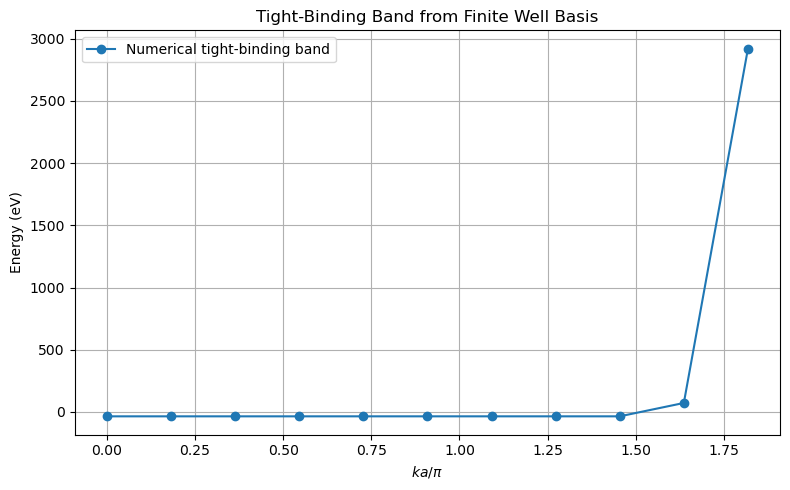

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# Domain and parameters
L = 30.0  # large enough to accommodate many sites
N_grid = 3000
x = np.linspace(-L/2, L/2, N_grid)
dx = x[1] - x[0]

V0 = -50.0
a = 3.0  # lattice spacing
well_width = 1.0

# 1. Finite well potential centered at 0
V_well = np.zeros_like(x)
V_well[np.abs(x) < well_width / 2] = V0

# Build Hamiltonian for single well
def build_hamiltonian(V):
    Lap = (-2 * np.eye(N_grid) + np.eye(N_grid, k=1) + np.eye(N_grid, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2/2m approx in eV Å^2
    H = T + np.diag(V)
    return H

H_well = build_hamiltonian(V_well)

# Solve for ground state orbital phi(x)
E_well, psi = eigh(H_well)
phi_0 = psi[:, 0]
phi_0 /= np.sqrt(trapezoid(phi_0**2, x))  # normalize

# 2. Build basis orbitals for lattice sites
def shift_orbital(phi, shift, x_grid):
    return np.interp(x_grid - shift, x_grid, phi, left=0, right=0)

# Number of lattice sites
N_sites = 11  # odd number for symmetry
sites = np.arange(-N_sites//2, N_sites//2 + 1)
orbitals = [shift_orbital(phi_0, n * a, x) for n in sites]

# 3 & 4. Compute overlap S and Hamiltonian H matrices
S = np.zeros((N_sites, N_sites))
H = np.zeros((N_sites, N_sites))

# Precompute total Hamiltonian operator (in real space)
# For this simple model, total potential is periodic array of wells
V_total = np.zeros_like(x)
for n in sites:
    V_total[np.abs(x - n*a) < well_width / 2] = V0
H_total = build_hamiltonian(V_total)

for i in range(N_sites):
    for j in range(N_sites):
        S[i, j] = trapezoid(orbitals[i] * orbitals[j], x)
        H_psi = H_total @ orbitals[j]
        H[i, j] = trapezoid(orbitals[i] * H_psi, x)

# 5. Apply periodic boundary conditions by identifying orbitals[N_sites] with orbitals[0]
# (Assuming indexing starts from 0, you may want to enforce cyclic structure)
# For simplicity, we’ll solve generalized eigenvalue problem directly

# 6. Solve generalized eigenvalue problem
E_vals, C = eigh(H, S)

# Plot band structure: k-points from discrete Fourier transform of coefficients
k_vals = 2 * np.pi * np.arange(N_sites) / (N_sites * a)
idx = np.argsort(k_vals)
k_vals = k_vals[idx]
E_vals = E_vals[idx]

plt.figure(figsize=(8,5))
plt.plot(k_vals * a / np.pi, E_vals, 'o-', label='Numerical tight-binding band')
plt.xlabel(r'$ka / \pi$')
plt.ylabel('Energy (eV)')
plt.title('Tight-Binding Band from Finite Well Basis')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# --- Domain and grid setup ---
L = 30.0
N_grid = 3000
x = np.linspace(-L/2, L/2, N_grid)
dx = x[1] - x[0]

# --- Potential parameters ---
V0 = -50.0
a = 3.0          # lattice constant
well_width = 1.0

# --- 1. Build single finite well potential centered at 0 ---
V_well = np.zeros_like(x)
V_well[np.abs(x) < well_width / 2] = V0

# --- Build Hamiltonian ---
def build_hamiltonian(V):
    Lap = (-2*np.eye(N_grid) + np.eye(N_grid, k=1) + np.eye(N_grid, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2/2m approx in eV·Å^2
    return T + np.diag(V)

# --- 2. Solve for single well ground state ---
H_well = build_hamiltonian(V_well)
E_well, psi = eigh(H_well)
phi_0 = psi[:, 0]
phi_0 /= np.sqrt(trapezoid(phi_0**2, x))  # Normalize

# --- 3. Build double well lattice potential for total Hamiltonian ---
V_total = np.zeros_like(x)
positions = [-a/2, a/2]  # two sites per unit cell at +/- a/2
for pos in positions:
    V_total[np.abs(x - pos) < well_width / 2] = V0

H_total = build_hamiltonian(V_total)

# --- 4. Define orbitals phi_A and phi_B centered at -a/2 and +a/2 ---
def shift_orbital(phi, shift, x_grid):
    return np.interp(x_grid - shift, x_grid, phi, left=0, right=0)

phi_A = shift_orbital(phi_0, -a/2, x)
phi_B = shift_orbital(phi_0, +a/2, x)

# Normalize again (just to be safe)
phi_A /= np.sqrt(trapezoid(phi_A**2, x))
phi_B /= np.sqrt(trapezoid(phi_B**2, x))

# --- 5. Calculate matrix elements ---
epsilon_A = trapezoid(np.conj(phi_A) * (H_total @ phi_A), x)
epsilon_B = trapezoid(np.conj(phi_B) * (H_total @ phi_B), x)

t = -trapezoid(np.conj(phi_A) * (H_total @ phi_B), x)

# Hopping to neighbor unit cell (shift B by +a)
phi_B_neighbor = shift_orbital(phi_B, a, x)
t_prime = -trapezoid(np.conj(phi_A) * (H_total @ phi_B_neighbor), x)

print(f"On-site energies: ε_A = {epsilon_A:.4f} eV, ε_B = {epsilon_B:.4f} eV")
print(f"Hopping integrals: t = {t:.4f} eV, t' = {t_prime:.4f} eV")

# --- 6. Build Bloch Hamiltonian and compute bands ---
k_points = np.linspace(-np.pi/a, np.pi/a, 300)
E_minus = []
E_plus = []

for k in k_points:
    Hk = np.array([[epsilon_A, t + t_prime * np.exp(-1j * k * a)],
                   [t + t_prime * np.exp(1j * k * a), epsilon_B]])
    energies, _ = eigh(Hk)
    E_minus.append(energies[0].real)
    E_plus.append(energies[1].real)

# --- 7. Plot bands ---
plt.figure(figsize=(8, 5))
plt.plot(k_points * a / np.pi, E_minus, label='Lower band')
plt.plot(k_points * a / np.pi, E_plu_*_


SyntaxError: incomplete input (2355205902.py, line 80)

On-site energies: ε_A = -35.0248 eV, ε_B = -35.0248 eV
Hopping integrals: t = 0.1059 eV, t' = 0.0000 eV


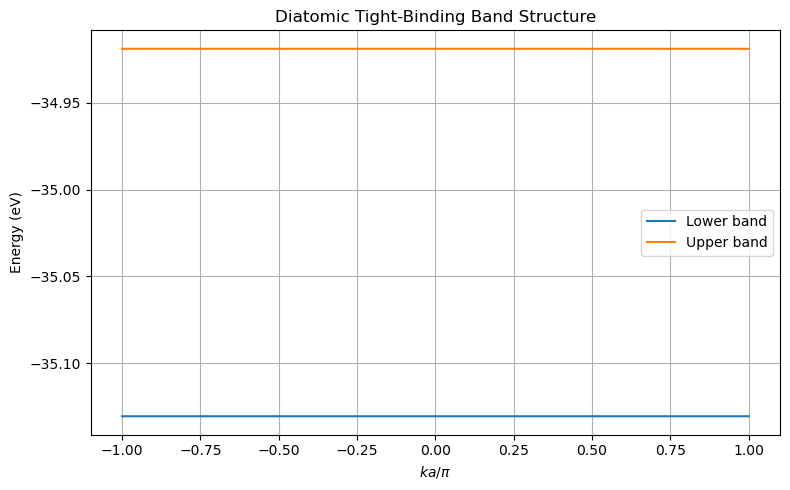

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.integrate import trapezoid

# --- Domain and grid setup ---
L = 30.0
N_grid = 3000
x = np.linspace(-L/2, L/2, N_grid)
dx = x[1] - x[0]

# --- Potential parameters ---
V0 = -50.0
a = 3.0          # lattice constant
well_width = 1.0

# --- 1. Build single finite well potential centered at 0 ---
V_well = np.zeros_like(x)
V_well[np.abs(x) < well_width / 2] = V0

# --- Build Hamiltonian ---
def build_hamiltonian(V):
    Lap = (-2*np.eye(N_grid) + np.eye(N_grid, k=1) + np.eye(N_grid, k=-1)) / dx**2
    T = -3.81 * Lap  # hbar^2/2m approx in eV·Å^2
    return T + np.diag(V)

# --- 2. Solve for single well ground state ---
H_well = build_hamiltonian(V_well)
E_well, psi = eigh(H_well)
phi_0 = psi[:, 0]
phi_0 /= np.sqrt(trapezoid(phi_0**2, x))  # Normalize

# --- 3. Build double well lattice potential for total Hamiltonian ---
V_total = np.zeros_like(x)
positions = [-a/2, a/2]  # two sites per unit cell at +/- a/2
for pos in positions:
    V_total[np.abs(x - pos) < well_width / 2] = V0

H_total = build_hamiltonian(V_total)

# --- 4. Define orbitals phi_A and phi_B centered at -a/2 and +a/2 ---
def shift_orbital(phi, shift, x_grid):
    return np.interp(x_grid - shift, x_grid, phi, left=0, right=0)

phi_A = shift_orbital(phi_0, -a/2, x)
phi_B = shift_orbital(phi_0, +a/2, x)

# Normalize again (just to be safe)
phi_A /= np.sqrt(trapezoid(phi_A**2, x))
phi_B /= np.sqrt(trapezoid(phi_B**2, x))

# --- 5. Calculate matrix elements ---
epsilon_A = trapezoid(np.conj(phi_A) * (H_total @ phi_A), x)
epsilon_B = trapezoid(np.conj(phi_B) * (H_total @ phi_B), x)

t = -trapezoid(np.conj(phi_A) * (H_total @ phi_B), x)

# Hopping to neighbor unit cell (shift B by +a)
phi_B_neighbor = shift_orbital(phi_B, a, x)
t_prime = -trapezoid(np.conj(phi_A) * (H_total @ phi_B_neighbor), x)

print(f"On-site energies: ε_A = {epsilon_A:.4f} eV, ε_B = {epsilon_B:.4f} eV")
print(f"Hopping integrals: t = {t:.4f} eV, t' = {t_prime:.4f} eV")

# --- 6. Build Bloch Hamiltonian and compute bands ---
k_points = np.linspace(-np.pi/a, np.pi/a, 300)
E_minus = []
E_plus = []

for k in k_points:
    Hk = np.array([[epsilon_A, t + t_prime * np.exp(-1j * k * a)],
                   [t + t_prime * np.exp(1j * k * a), epsilon_B]])
    energies, _ = eigh(Hk)
    E_minus.append(energies[0].real)
    E_plus.append(energies[1].real)

# --- 7. Plot bands ---
plt.figure(figsize=(8, 5))
plt.plot(k_points * a / np.pi, E_minus, label='Lower band')
plt.plot(k_points * a / np.pi, E_plus, label='Upper band')
plt.xlabel(r'$ka / \pi$')
plt.ylabel('Energy (eV)')
plt.title('Diatomic Tight-Binding Band Structure')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

